In [39]:
from read_transcription import *
from normalise_text import *
import os
path="/vol/corpora/TAPAS_FRAIS/Data_partagees_ParisTypaloc-TapasFrais/12-CTRL/"
csv='/vol/experiments3/imbenamor/TAPAS-FRAIS/logs/csv_files/typaloc/conf_ester_ctrl_vad_chunk.csv'
ref=[]
files_id=[]
tmp=pd.read_csv(csv)
files = list(tmp["file"])
for f in files:
    print(f)
    files_id.append(f.split(".")[0])
    ref_transcriptions = get_textgrid_transcription_tapas(path+f.split(".")[0]+".TextGrid")
    ref.append(" ".join(normalization(ref_transcriptions)))


AEX-CAB000-02_L01.wav
AEX-CAC000-02_L01.wav
AEX-CAG000-01_L01.wav
AEX-CLJ000-02_L01.wav
AEX-CML000-01_L01.wav
AEX-CSR000-01_L01.wav
BEX-CDB000-01_L01.wav
BEX-CEB000-01_L01.wav
BEX-CHE000-01_L01.wav
BEX-CKN000-01_L01.wav
BEX-CMB000-01_L01.wav
BEX-CNKN00-01_L01.wav


In [40]:
def write_ref_trn(texts, file_ids, out_path="ref.trn"):
    if len(texts) != len(file_ids):
        raise ValueError("texts et file_ids doivent avoir la même longueur")

    with open(out_path, "w", encoding="utf-8") as f:
        for text, fid in zip(texts, file_ids):
            text = text.strip()
            f.write(f"{text} ({fid})\n")


# Utilisation
write_ref_trn(ref, files_id, "ref_typaloc_ctrl.trn")


In [55]:
import pandas as pd
import re

def load_ref_trn(ref_trn_path):
    """
    Lit un fichier ref.trn et retourne un dict :
    { file_id : nombre_de_mots }
    """
    ref_dict = {}

    with open(ref_trn_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Séparer texte et id (contenu entre parenthèses)
            match = re.match(r"(.+?)\s*\((.+?)\)", line)
            if not match:
                raise ValueError(f"Ligne invalide dans ref.trn : {line}")

            text = match.group(1).strip()
            file_id = match.group(2).strip()

            # Tokenisation simple (doit matcher celle utilisée pour S/D/I)
            tokens = text.split()
            ref_dict[file_id] = len(tokens)

    return ref_dict


def compute_corpus_wer(csv_path, ref_trn_path):
    # Charger le CSV
    df = pd.read_csv(csv_path)

    # Charger le ref.trn
    ref_word_counts = load_ref_trn(ref_trn_path)

    # Ajouter N à partir du ref.trn
    def get_N(file_name):
        
            
        file_id = file_name.split("-")[1].split(".")[0]+"-Rhap"  # audio1.wav -> audio1
          
        if file_id not in ref_word_counts:
            raise KeyError(f"{file_id} absent de ref.trn")
        return ref_word_counts[file_id]

    df["N"] = df["file"].apply(get_N)
    # Sommes globales
    total_S = df["S"].sum()
    total_D = df["D"].sum()
    total_I = df["I"].sum()
    total_N = df["N"].sum()

    wer_corpus = (total_S + total_D + total_I) / total_N

    return wer_corpus, {
        "S": total_S,
        "D": total_D,
        "I": total_I,
        "N": total_N,
    }




In [63]:
import os
path ="/vol/experiments3/imbenamor/TAPAS-FRAIS/logs/csv_files/rhap/"
for csv_path in os.listdir(path):
    ref_trn_path = "ref.trn"
    print(csv_path)
    if csv_path !="rhap_sans_hesitation_ni_rep.csv" and csv_path !="w2v_rhap.csv" and csv_path !="rhap_sans_hesitation.csv" :
        wer, details = compute_corpus_wer(path+csv_path, ref_trn_path)
        
        print("===== WER CORPUS =====")
        print(f"S = {details['S']}")
        print(f"D = {details['D']}")
        print(f"I = {details['I']}")
        print(f"N = {details['N']}")
        print(f"WER corpus = {wer * 100:.2f}%")


whisper_vad-chunk_rhap_rvad.csv
===== WER CORPUS =====
S = 2313
D = 13754
I = 494
N = 32418
WER corpus = 51.09%
w2v_rhap_vad_chunk.csv
===== WER CORPUS =====
S = 3543
D = 4420
I = 659
N = 32418
WER corpus = 26.60%
whisper_vad_chunk_rhap_silero.csv
===== WER CORPUS =====
S = 1823
D = 15939
I = 328
N = 32418
WER corpus = 55.80%
rhap_sans_hesitation_ni_rep.csv
rhap_conf_ester_silero.csv
===== WER CORPUS =====
S = 4050
D = 1978
I = 707
N = 32418
WER corpus = 20.78%
hmm_tdnn_rhap.csv
===== WER CORPUS =====
S = 4159
D = 3931
I = 391
N = 32418
WER corpus = 26.16%
hmm_tdnn_rhap_vad_chunk.csv
===== WER CORPUS =====
S = 4268
D = 3213
I = 933
N = 32418
WER corpus = 25.95%
conf_rhap_silero.csv
===== WER CORPUS =====
S = 377
D = 331
I = 44
N = 4982
WER corpus = 15.09%
whisper_large-vad-chunk_rhap_rvad.csv
===== WER CORPUS =====
S = 2626
D = 11816
I = 644
N = 32418
WER corpus = 46.54%
w2v_rhap.csv
conf_ester_rhap_vad_chunk.csv
===== WER CORPUS =====
S = 4024
D = 1557
I = 1410
N = 32418
WER corpus = 

In [2]:
df

,dataset,category,model,wer
0,Tapas,,W2V,22.08
1,Tapas,,Whisper-large,25.11
2,Tapas,,Conf(ester),21.28
3,Tapas,,Conf(cv),24.64
4,Tapas,,Hmm-Tdnn,24.34
5,Rhapsodie,Planifié,W2V,17.19
6,Rhapsodie,Semi-spontané,W2V,29.87
7,Rhapsodie,Spontané,W2V,32.69
8,Rhapsodie,Planifié,Whisper-large,36.07
9,Rhapsodie,Semi-spontané,Whisper-large,48.33


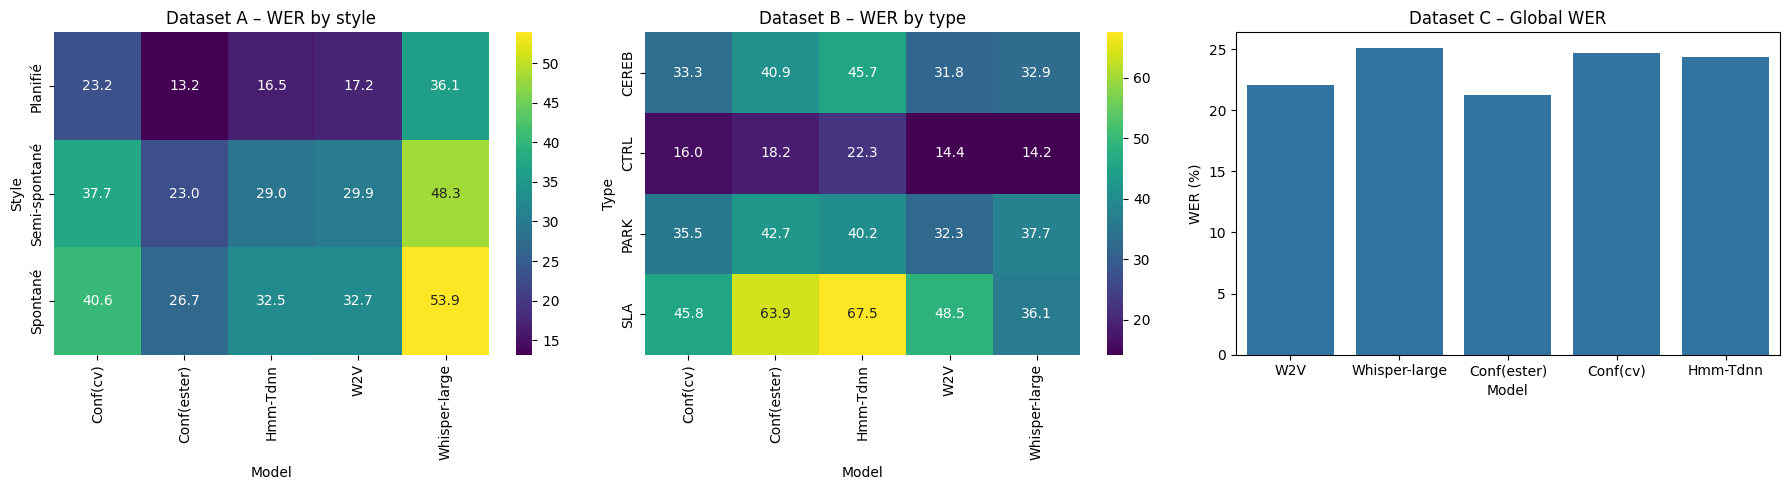

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# exemple de dataframe
df = pd.DataFrame({
    "dataset": ["Tapas"]*5+["Rhapsodie"]*15 + ["Typaloc"]*20,
    "category": [""]*5+["Planifié","Semi-spontané","Spontané"]*5
                + ["PARK","CEREB","SLA","CTRL"]*5,
    "model": ["W2V","Whisper-large","Conf(ester)","Conf(cv)","Hmm-Tdnn"]+sum([[i]*3 for i in ["W2V","Whisper-large","Conf(ester)","Conf(cv)","Hmm-Tdnn"]], [] )
+sum([[i]*4 for i in ["W2V","Whisper-large","Conf(ester)","Conf(cv)","Hmm-Tdnn"]], [] )
,
    "wer": [22.08,25.11,21.28,24.64,24.34,17.19,29.87,32.69,36.07,48.33,53.90,13.16,22.97,26.73,23.18,37.66,40.64,16.53,29,32.48,32.31,31.77,48.45,14.40,37.73,32.89,36.12,14.21,42.69,40.92,63.92,18.23,35.52,33.26,45.77,16,40.21,45.68,67.52,22.34]
})

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Dataset A — heatmap
pivot_A = df[df.dataset=="Rhapsodie"].pivot(
    index="category", columns="model", values="wer"
)
sns.heatmap(pivot_A, annot=True, fmt=".1f",
            cmap="viridis", ax=axes[0])
axes[0].set_title("Dataset A – WER by style")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Style")

# Dataset B — heatmap
pivot_B = df[df.dataset=="Typaloc"].pivot(
    index="category", columns="model", values="wer"
)
sns.heatmap(pivot_B, annot=True, fmt=".1f",
            cmap="viridis", ax=axes[1])
axes[1].set_title("Dataset B – WER by type")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Type")

# Dataset C — barplot (no category)
sns.barplot(
    data=df[df.dataset=="Tapas"],
    x="model",
    y="wer",
    ax=axes[2]
)
axes[2].set_title("Dataset C – Global WER")
axes[2].set_xlabel("Model")
axes[2].set_ylabel("WER (%)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_2734259/1713775799.py:42: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30)


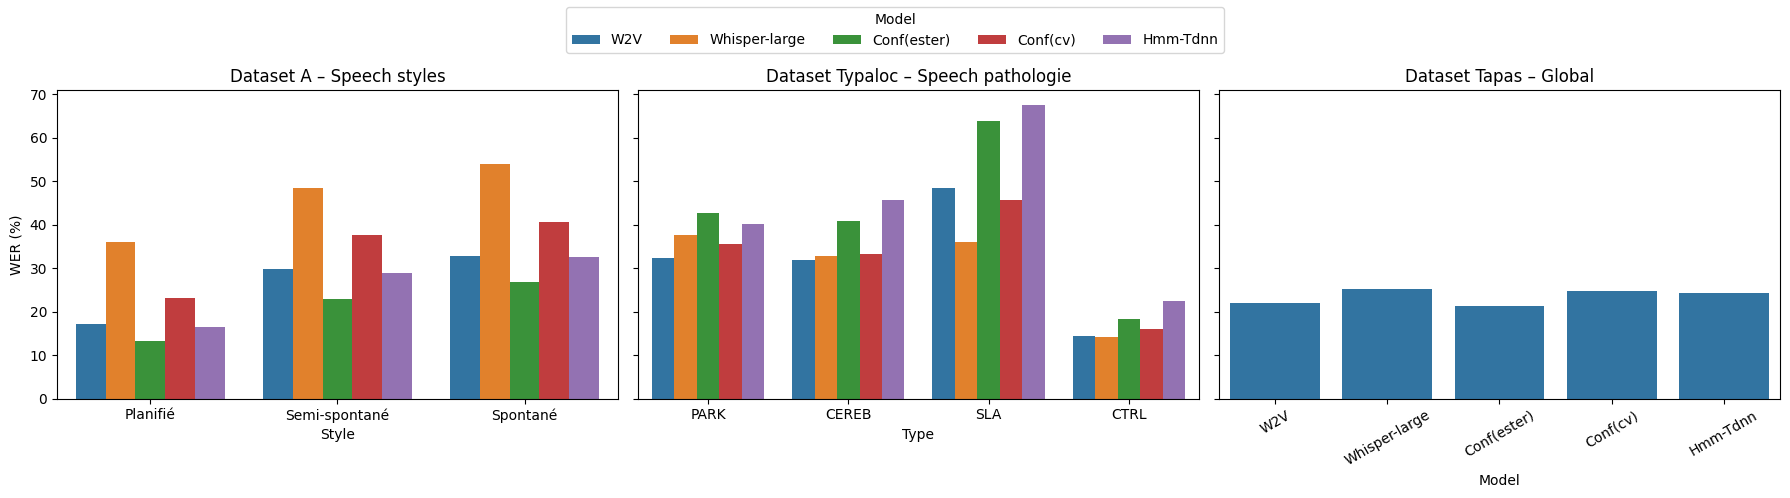

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

# Dataset A
sns.barplot(
    data=df[df.dataset=="Rhapsodie"],
    x="category",
    y="wer",
    hue="model",
    ax=axes[0]
)
axes[0].set_title("Dataset A – Speech styles")
axes[0].set_xlabel("Style")
axes[0].set_ylabel("WER (%)")
axes[0].legend_.remove()

# Dataset B
sns.barplot(
    data=df[df.dataset=="Typaloc"],
    x="category",
    y="wer",
    hue="model",
    ax=axes[1]
)
axes[1].set_title("Dataset Typaloc – Speech pathologie")
axes[1].set_xlabel("Type")
axes[1].set_ylabel("")
axes[1].legend_.remove()

# Dataset C (global)
sns.barplot(
    data=df[df.dataset=="Tapas"],
    x="model",
    y="wer",
    ax=axes[2]
)
axes[2].set_title("Dataset Tapas – Global")
axes[2].set_xlabel("Model")
axes[2].set_ylabel("")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30)

# Légende commune
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Model",
    loc="upper center",
    ncol=5
)

plt.tight_layout(rect=[0,0,1,0.9])
plt.show()



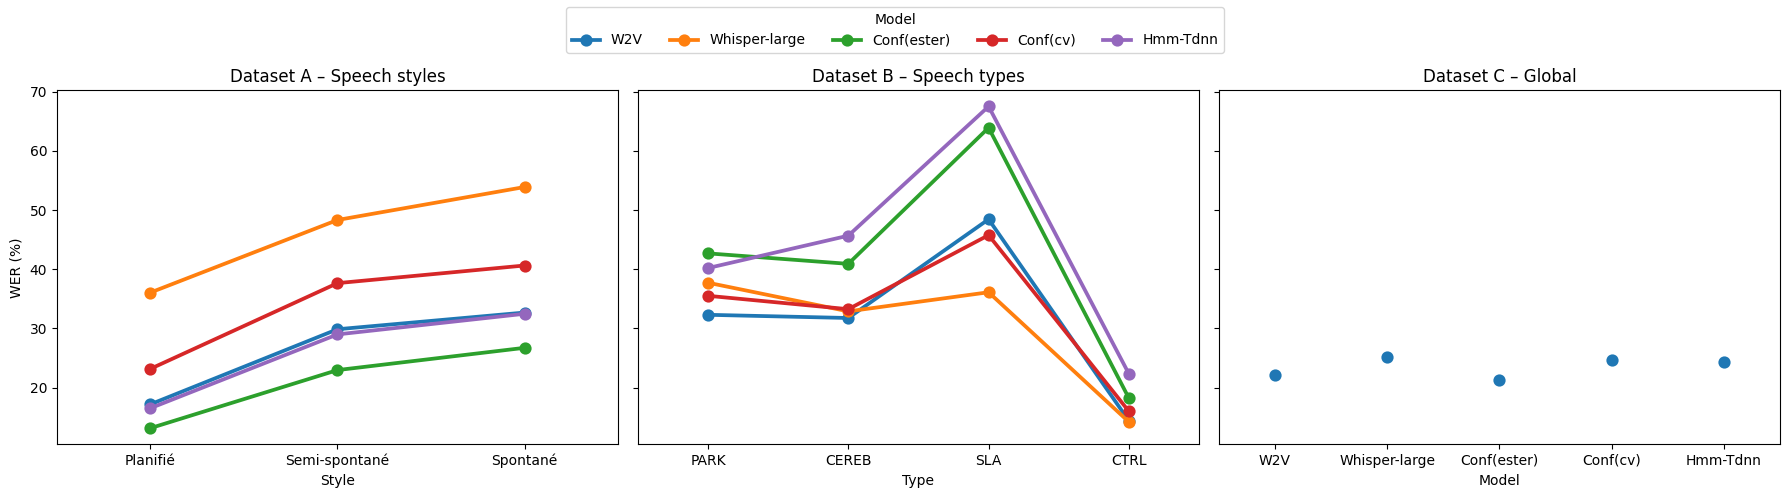

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

# Dataset A
sns.pointplot(
    data=df[df.dataset=="Rhapsodie"],
    x="category",
    y="wer",
    hue="model",
    markers="o",
    linestyles="-",
    ax=axes[0]
)
axes[0].set_title("Dataset A – Speech styles")
axes[0].set_xlabel("Style")
axes[0].set_ylabel("WER (%)")
axes[0].legend_.remove()

# Dataset B
sns.pointplot(
    data=df[df.dataset=="Typaloc"],
    x="category",
    y="wer",
    hue="model",
    markers="o",
    linestyles="-",
    ax=axes[1]
)
axes[1].set_title("Dataset B – Speech types")
axes[1].set_xlabel("Type")
axes[1].set_ylabel("")
axes[1].legend_.remove()

# Dataset C (global)
sns.pointplot(
    data=df[df.dataset=="Tapas"],
    x="model",
    y="wer",
    markers="o",
    linestyles="",
    ax=axes[2]
)
axes[2].set_title("Dataset C – Global")
axes[2].set_xlabel("Model")
axes[2].set_ylabel("")

# Légende commune
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Model",
    loc="upper center",
    ncol=5
)

plt.tight_layout(rect=[0,0,1,0.9])
plt.show()


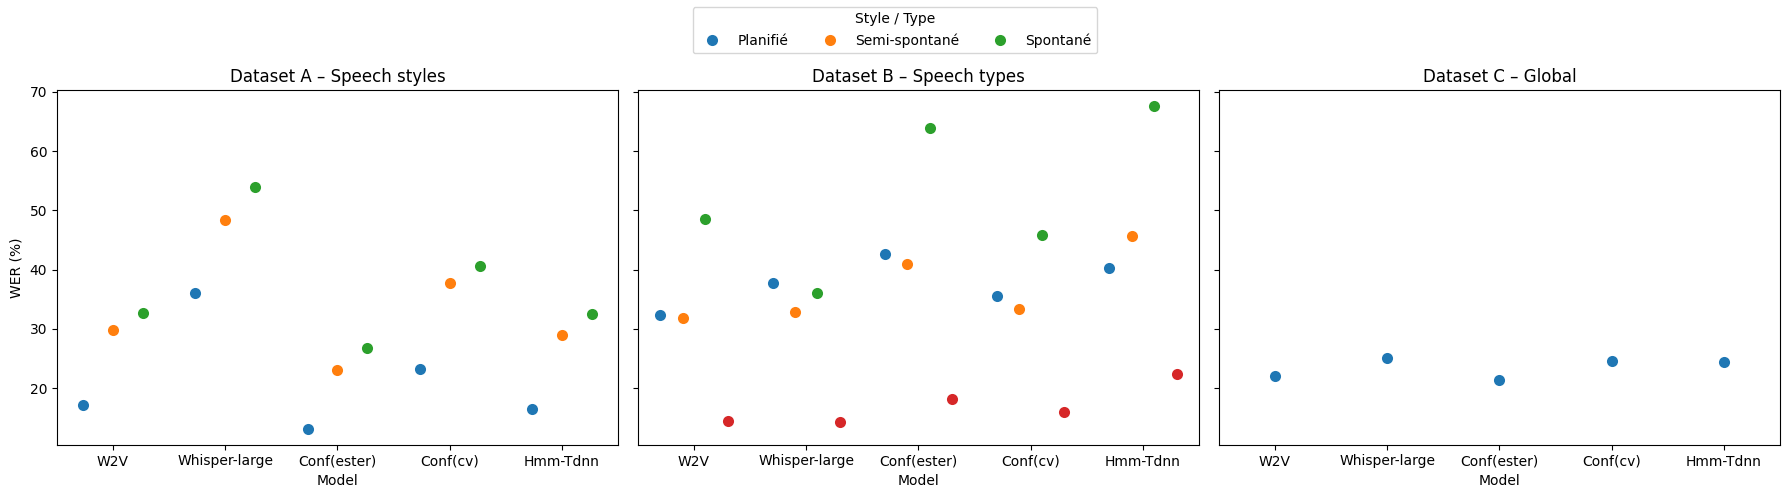

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

# Dataset A — styles
sns.stripplot(
    data=df[df.dataset=="Rhapsodie"],
    x="model",
    y="wer",
    hue="category",
    dodge=True,
    jitter=False,
    size=8,
    ax=axes[0]
)
axes[0].set_title("Dataset A – Speech styles")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("WER (%)")
axes[0].legend_.remove()

# Dataset B — types
sns.stripplot(
    data=df[df.dataset=="Typaloc"],
    x="model",
    y="wer",
    hue="category",
    dodge=True,
    jitter=False,
    size=8,
    ax=axes[1]
)
axes[1].set_title("Dataset B – Speech types")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("")
axes[1].legend_.remove()

# Dataset C — global (pas de catégorie)
sns.stripplot(
    data=df[df.dataset=="Tapas"],
    x="model",
    y="wer",
    size=8,
    ax=axes[2]
)
axes[2].set_title("Dataset C – Global")
axes[2].set_xlabel("Model")
axes[2].set_ylabel("")

# Légende commune (catégories)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Style / Type",
    loc="upper center",
    ncol=3
)

plt.tight_layout(rect=[0,0,1,0.9])
plt.show()

